# Sprint 33 — Profilage énergétique & métriques de coût

**Objectif** : caractériser le **coût** des 4 modèles (EWC, HDC, TinyOL, Mahalanobis) sur NUCLEO-F439ZI —
coût de calcul (FLOPs / **BOPs** / paramètres), coût matériel (latence board inférence vs mise à jour),
coût mémoire (RAM), et — dès qu'une sonde sera posée — coût énergétique (µJ) et autonomie.

**Règle projet « aucun chiffre inventé »** : la sonde **PowerShield X-NUCLEO-LPM01A n'est pas encore posée**.
La chaîne de capture/segmentation est fonctionnelle (`scripts/energy_capture.py`, 16 tests PASS) mais les
champs énergie/autonomie portent la valeur littérale **`"à mesurer"`** tant qu'aucun CSV réel n'est capturé.
**Aucune valeur énergétique n'est fabriquée ici.**

**Source de vérité** :
- Coût calcul : `src/evaluation/compute_cost.py` (FLOPs/BOPs/Params analytiques — réels)
- Latence board : `experiments/exp_S33_board_latency/latency_summary.json` (réelle)
- RAM / accuracy PC : `experiments/exp_S33_PC_{model}_{dataset}/results.json` (réelle)
- Énergie / autonomie : `experiments/exp_S33_energy/{summary,autonomy}.json` (placeholders « à mesurer »)


In [1]:
import json, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

ROOT = Path.cwd()
if not (ROOT / "experiments").exists():
    ROOT = ROOT.parent
assert (ROOT / "experiments").exists()
sys.path.insert(0, str(ROOT))
EXP = ROOT / "experiments"

from src.evaluation.compute_cost import (
    compute_flops_for_model, compute_bops_for_model, compute_params_for_model,
)
MCOLOR = {"ewc": "#1f77b4", "hdc": "#ff7f0e", "tinyol": "#2ca02c", "mahalanobis": "#9467bd"}
A_MESURER = "à mesurer"
print("ROOT =", ROOT)

ROOT = /home/leonard/Documents/ENAC/cl-embedded


## 1. Coût de calcul — FLOPs, BOPs, paramètres (réel, analytique)

Dimensions de référence **board (5 features)** : EWC MLP `5→32→16→2`, HDC `dim_hv=1000`,
TinyOL encodeur `5→16→8`, Mahalanobis `5`. BOPs = FLOPs × n_bits² → ratio FP32/INT8 = (32/8)² = **16**.

In [2]:
# Dimensions board (5-feat) — toute taille a une constante explicite (règle projet)
N_FEAT, N_CLASSES = 5, 2
SPECS = {
    "ewc":         ("EWC",         dict(n_features=N_FEAT, hidden_dims=[32, 16], n_classes=N_CLASSES)),
    "hdc":         ("HDC",         dict(n_features=N_FEAT, dim_hv=1000, n_classes=N_CLASSES)),
    "tinyol":      ("TinyOL",      dict(n_features=N_FEAT, encoder_dims=[16, 8], n_classes=N_CLASSES)),
    "mahalanobis": ("Mahalanobis", dict(n_features=N_FEAT)),
}
rows = []
for key, (name, kw) in SPECS.items():
    flops = compute_flops_for_model(name, **kw)
    bops_fp32 = compute_bops_for_model(name, 32, **kw)
    bops_int8 = compute_bops_for_model(name, 8, **kw)
    params = compute_params_for_model(name, **kw)
    rows.append({"model": key, "flops": flops, "params": params,
                 "bops_fp32": bops_fp32, "bops_int8": bops_int8,
                 "bops_ratio_fp32_int8": bops_fp32 / bops_int8})
cost = pd.DataFrame(rows)
print("Ratio BOPs FP32/INT8 (théorique (32/8)^2 = 16) :", sorted(cost.bops_ratio_fp32_int8.unique()))
cost

Ratio BOPs FP32/INT8 (théorique (32/8)^2 = 16) : [np.float64(16.0)]


,model,flops,params,bops_fp32,bops_int8,bops_ratio_fp32_int8
0,ewc,1408,754,1441792,90112,16.0
1,hdc,14000,7000,14336000,896000,16.0
2,tinyol,448,250,458752,28672,16.0
3,mahalanobis,60,30,61440,3840,16.0


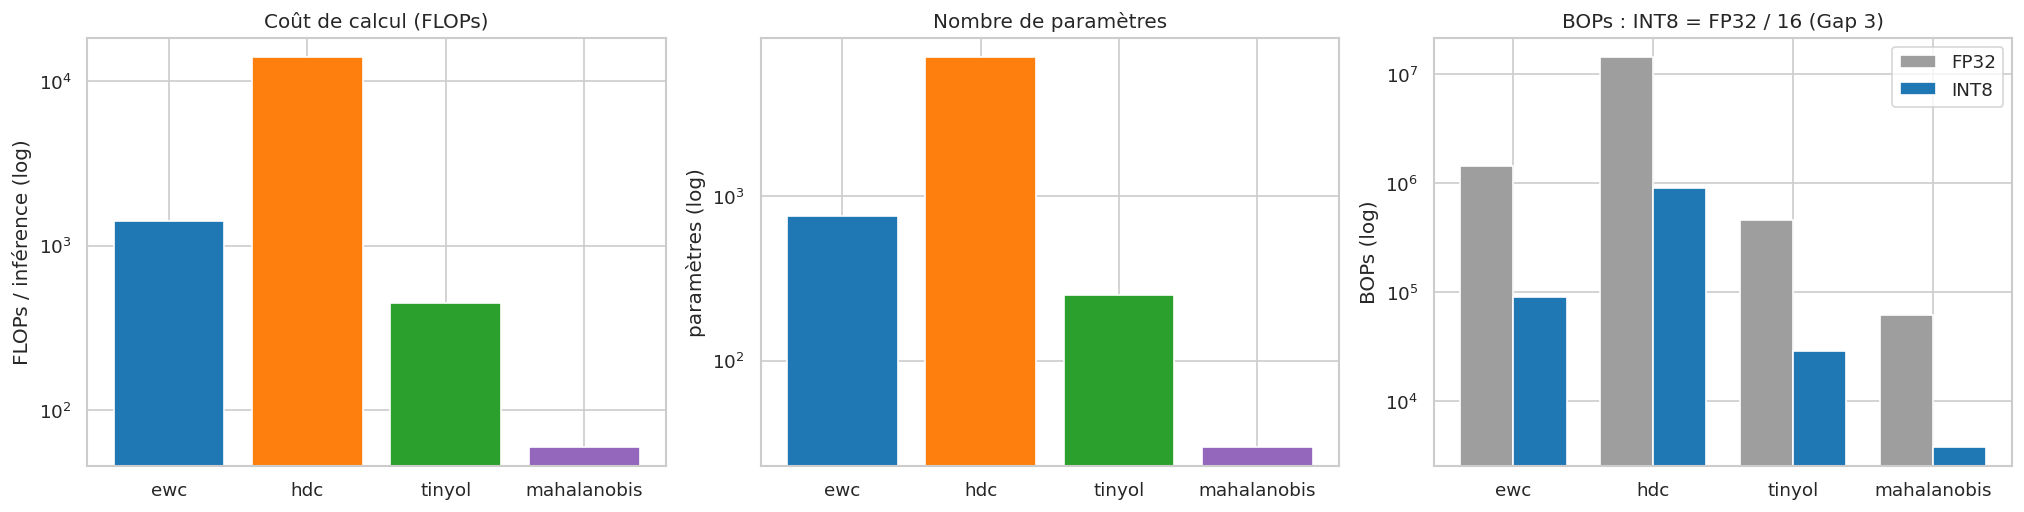

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
order = list(SPECS)
cols = [c for c in order]
# FLOPs
axes[0].bar(order, cost.set_index("model").loc[order, "flops"],
            color=[MCOLOR[m] for m in order])
axes[0].set_yscale("log"); axes[0].set_ylabel("FLOPs / inférence (log)"); axes[0].set_title("Coût de calcul (FLOPs)")
# Params
axes[1].bar(order, cost.set_index("model").loc[order, "params"],
            color=[MCOLOR[m] for m in order])
axes[1].set_yscale("log"); axes[1].set_ylabel("paramètres (log)"); axes[1].set_title("Nombre de paramètres")
# BOPs FP32 vs INT8
x = np.arange(len(order)); w = 0.38
ci = cost.set_index("model").loc[order]
axes[2].bar(x - w/2, ci["bops_fp32"], w, label="FP32", color="#9e9e9e")
axes[2].bar(x + w/2, ci["bops_int8"], w, label="INT8", color="#1f77b4")
axes[2].set_yscale("log"); axes[2].set_xticks(x); axes[2].set_xticklabels(order)
axes[2].set_ylabel("BOPs (log)"); axes[2].set_title("BOPs : INT8 = FP32 / 16 (Gap 3)"); axes[2].legend()
plt.tight_layout(); plt.show()

## 2. Coût matériel — latence board inférence vs inférence+update (réel)

Mesures DWT sur NUCLEO-F439ZI. Toutes ≪ **Gap 2 (≤ 100 ms)**. L'update (apprentissage en ligne) coûte
surtout pour EWC et HDC ; nul pour Mahalanobis/TinyOL (pas de rétropropagation embarquée ici).

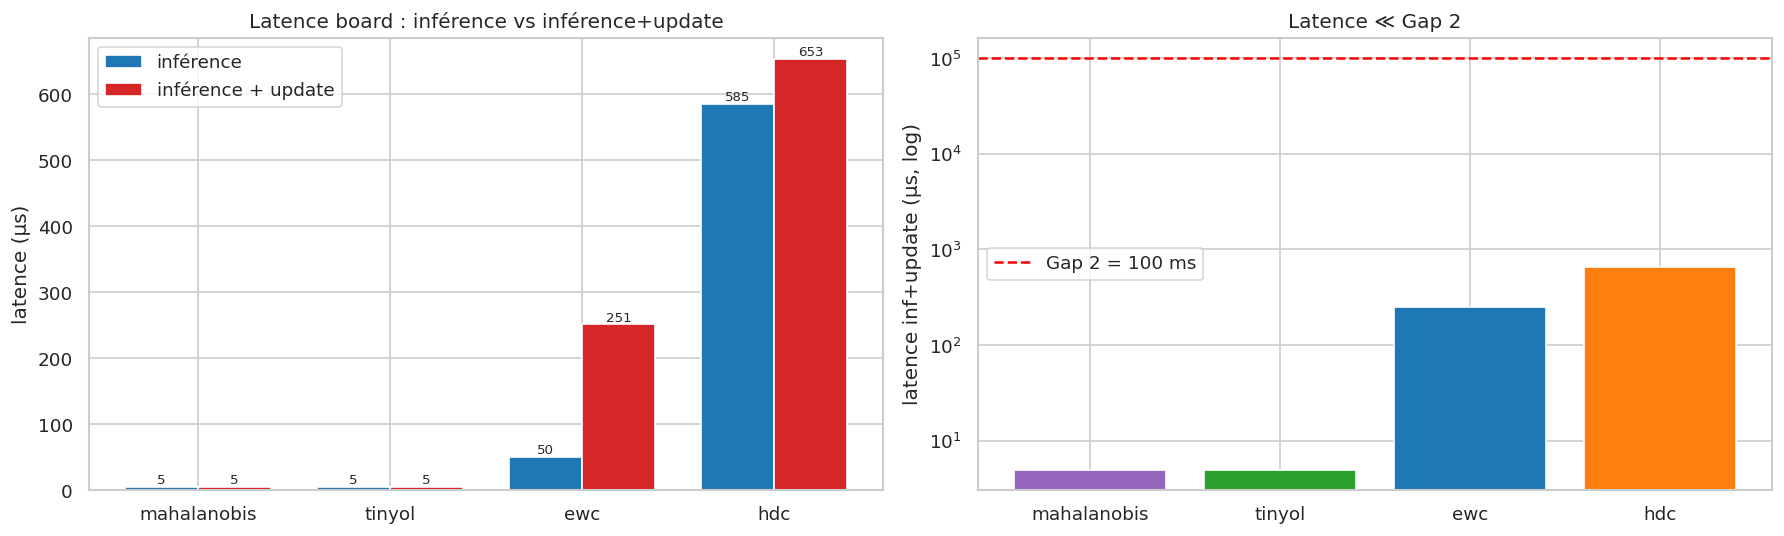

Marge Gap 2 (inf+update) : {'mahalanobis': 20000, 'tinyol': 20000, 'ewc': 398, 'hdc': 153} ×


In [4]:
lat = pd.DataFrame(json.loads((EXP / "exp_S33_board_latency" / "latency_summary.json").read_text()))
order = ["mahalanobis", "tinyol", "ewc", "hdc"]
lat = lat.set_index("model").loc[order].reset_index()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6))
x = np.arange(len(order)); w = 0.38
ax1.bar(x - w/2, lat["latency_inf_us"], w, label="inférence", color="#1f77b4")
ax1.bar(x + w/2, lat["latency_inf_update_us"], w, label="inférence + update", color="#d62728")
ax1.set_xticks(x); ax1.set_xticklabels(order); ax1.set_ylabel("latence (µs)")
ax1.set_title("Latence board : inférence vs inférence+update"); ax1.legend()
for i, (a, b) in enumerate(zip(lat["latency_inf_us"], lat["latency_inf_update_us"])):
    ax1.text(i - w/2, a + 5, f"{a:.0f}", ha="center", fontsize=8)
    ax1.text(i + w/2, b + 5, f"{b:.0f}", ha="center", fontsize=8)

ax2.bar(x, lat["latency_inf_update_us"], color=[MCOLOR[m] for m in order])
ax2.axhline(100_000, color="red", ls="--", label="Gap 2 = 100 ms")
ax2.set_yscale("log"); ax2.set_xticks(x); ax2.set_xticklabels(order)
ax2.set_ylabel("latence inf+update (µs, log)"); ax2.set_title("Latence ≪ Gap 2"); ax2.legend()
plt.tight_layout(); plt.show()
print("Marge Gap 2 (inf+update) :",
      {m: round(100_000 / v) for m, v in zip(order, lat["latency_inf_update_us"])}, "×")

## 3. Coût mémoire & performance PC (réel)

12/12 runs PC valides


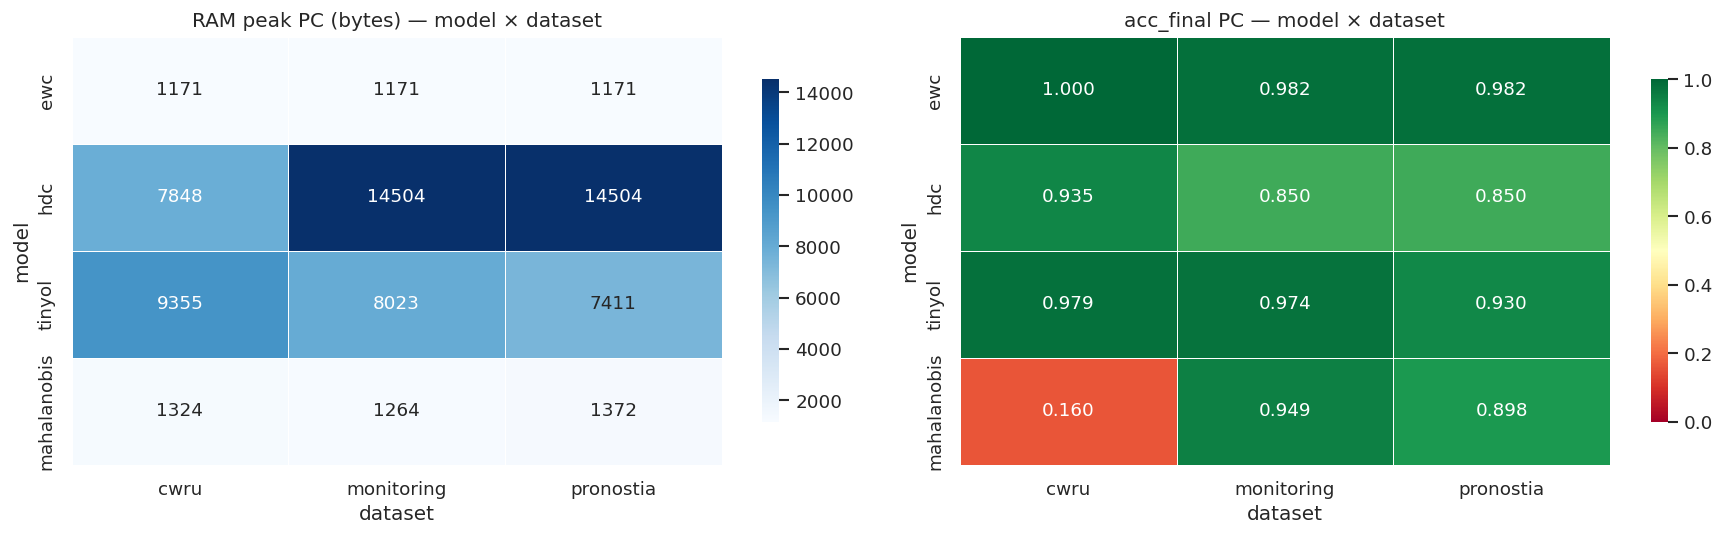

,model,dataset,status,acc_final,ram_peak_bytes,inference_latency_ms,n_params
0,ewc,cwru,ok,1.0000,1171,0.0305,865
1,ewc,monitoring,ok,0.9817,1171,0.0295,705
2,ewc,pronostia,ok,0.9819,1171,0.0331,993
3,hdc,cwru,ok,0.9351,7848,0.0630,1024
4,hdc,monitoring,ok,0.8498,14504,0.0357,2048
5,hdc,pronostia,ok,0.8503,14504,0.0873,2048
6,tinyol,cwru,ok,0.9788,9355,0.0084,478
7,tinyol,monitoring,ok,0.9741,8023,0.0064,398
8,tinyol,pronostia,ok,0.9297,7411,0.0073,542
9,mahalanobis,cwru,ok,0.1602,1324,0.0058,90


In [5]:
MODELS = ["ewc", "hdc", "tinyol", "mahalanobis"]
DATASETS = ["cwru", "monitoring", "pronostia"]
prows = []
for m in MODELS:
    for ds in DATASETS:
        f = EXP / f"exp_S33_PC_{m}_{ds}" / "results.json"
        if not f.exists():
            prows.append({"model": m, "dataset": ds, "status": "missing"}); continue
        r = json.loads(f.read_text())
        prows.append({"model": m, "dataset": ds, "status": "ok",
                      "acc_final": r.get("acc_final"),
                      "ram_peak_bytes": r.get("ram_peak_bytes"),
                      "inference_latency_ms": r.get("inference_latency_ms"),
                      "n_params": r.get("n_params")})
pc = pd.DataFrame(prows)
print(f"{(pc.status=='ok').sum()}/{len(pc)} runs PC valides")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.6))
piv_ram = pc[pc.status=="ok"].pivot_table(index="model", columns="dataset", values="ram_peak_bytes").reindex(MODELS)
sns.heatmap(piv_ram, annot=True, fmt=".0f", cmap="Blues", ax=ax1, linewidths=.5, cbar_kws={"shrink":.8})
ax1.set_title("RAM peak PC (bytes) — model × dataset")
piv_acc = pc[pc.status=="ok"].pivot_table(index="model", columns="dataset", values="acc_final").reindex(MODELS)
sns.heatmap(piv_acc, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax2, linewidths=.5, cbar_kws={"shrink":.8})
ax2.set_title("acc_final PC — model × dataset")
plt.tight_layout(); plt.show()
pc[pc.status=="ok"].round(4)

## 4. Coût énergétique & autonomie — structure prête, valeurs « à mesurer »

La chaîne `energy_capture.py` (segmentation par fronts du marqueur GPIO **PA8**, intégration µJ) est
fonctionnelle et testée. Tant que la sonde LPM01A n'est pas posée, **tous les champs énergie/autonomie
restent `"à mesurer"`** — on affiche ici la structure (modèles × encodage × phases) prête à re-remplir
depuis un CSV réel, **sans tracer de valeur fabriquée**.

In [6]:
esum = json.loads((EXP / "exp_S33_energy" / "summary.json").read_text())
print("Phases instrumentées :", esum["phases"])
print("Note Gap 3 :", esum["gap3_note"][:200], "...\n")
# Tableau d'état de la campagne énergie (montre explicitement 'à mesurer')
erows = [{"model": m, **{k: v for k, v in d.items()}} for m, d in esum["per_model"].items()]
edf = pd.DataFrame(erows)
n_pending = (edf.drop(columns="model") == A_MESURER).sum().sum()
print(f"Champs énergie en attente de mesure : {n_pending}/{edf.drop(columns='model').size} (= '{A_MESURER}')")
edf

Phases instrumentées : ['startup', 'acquisition', 'inference', 'idle']
Note Gap 3 : Sprint 29 : l'INT8 réduit la RAM sans accélérer la latence (FPU Cortex-M4, pas de NPU INT8). Question énergie : l'INT8 réduit-il néanmoins les µJ (moins d'accès mémoire) ? — réponse via mesures LPM01A ...

Champs énergie en attente de mesure : 16/16 (= 'à mesurer')


,model,fp32,int8,delta_uj,ratio_int8_fp32
0,ewc,à mesurer,à mesurer,à mesurer,à mesurer
1,hdc,à mesurer,à mesurer,à mesurer,à mesurer
2,tinyol,à mesurer,à mesurer,à mesurer,à mesurer
3,maha,à mesurer,à mesurer,à mesurer,à mesurer


Capacités batterie balayées (mAh) : [220.0, 1200.0, 2000.0, 3000.0, 10000.0] | tension : 3.3 V
RAM peak du calcul autonomy.py (tracemalloc PC, réel) : 208 B — within_budget_64ko: True


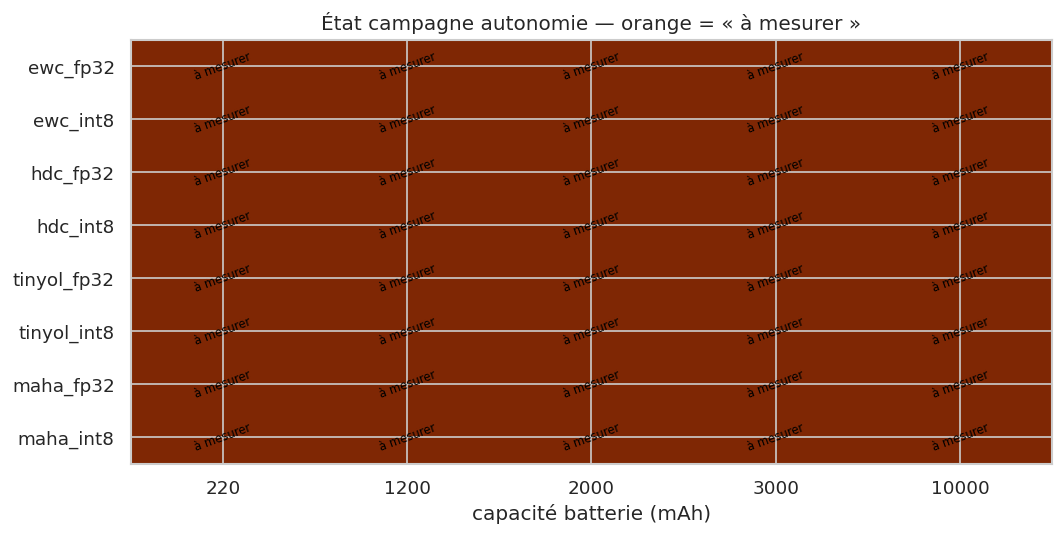

In [7]:
auto = json.loads((EXP / "exp_S33_energy" / "autonomy.json").read_text())
caps = auto["capacites_mah"]
ram_proxy = auto.get("ram_profiling", {})
print("Capacités batterie balayées (mAh) :", caps, "| tension :", auto["tension_v"], "V")
print("RAM peak du calcul autonomy.py (tracemalloc PC, réel) :",
      ram_proxy.get("ram_peak_bytes"), "B — within_budget_64ko:", ram_proxy.get("within_budget_64ko"))

# Matrice d'état autonomie : modèle×encodage × capacité (toutes cellules 'à mesurer')
idx, data = [], []
for mk, d in auto["per_model"].items():
    idx.append(mk)
    data.append([1 if d["autonomy_h_by_mah"][str(c)] == A_MESURER else 0 for c in caps])
mat = np.array(data)
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.imshow(mat, cmap="Oranges", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(caps))); ax.set_xticklabels([f"{c:.0f}" for c in caps])
ax.set_yticks(range(len(idx))); ax.set_yticklabels(idx)
ax.set_xlabel("capacité batterie (mAh)"); ax.set_title("État campagne autonomie — orange = « à mesurer »")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, A_MESURER, ha="center", va="center", fontsize=7, color="black", rotation=20)
plt.tight_layout(); plt.show()

## 5. Conclusion

- **Coût de calcul (réel)** : FLOPs/paramètres séparent nettement les modèles (HDC dominé par la
  dimension HV, Mahalanobis le plus léger). Le **ratio BOPs FP32/INT8 = 16** quantifie honnêtement le
  gain de l'INT8 sur le nombre d'opérations binaires.
- **Coût matériel (réel)** : latence inférence vs inférence+update mesurée sur board ; l'update pèse
  pour EWC/HDC, négligeable pour Maha/TinyOL. **Toutes ≪ Gap 2 (≤ 100 ms)**.
- **Lien Gap 3** : l'INT8 réduit la RAM (Sprint 29) **sans accélérer la latence** (FPU Cortex-M4, pas de
  NPU INT8). La question « l'INT8 réduit-il les µJ ? » reste **ouverte** — réponse conditionnée à des
  mesures LPM01A réelles.
- **Énergie / autonomie** : chaîne de capture **fonctionnelle et testée**, mais valeurs `"à mesurer"`
  tant que la sonde n'est pas posée. Aucun chiffre énergétique inventé dans ce notebook.

*Coûts calcul/latence/RAM/accuracy : valeurs réelles depuis `compute_cost.py` et `exp_S33_*`.
Énergie/autonomie : placeholders `"à mesurer"`, prêts à re-remplir depuis un CSV LPM01A.*